In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [3]:
df = pd.read_csv("../../data/processed/cleaned_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (48187, 12)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,day,month
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10


In [4]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 48187 entries, 0 to 48186
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48187 non-null  float64
 2   rain_1h              48187 non-null  float64
 3   snow_1h              48187 non-null  float64
 4   clouds_all           48187 non-null  int64  
 5   weather_main         48187 non-null  str    
 6   weather_description  48187 non-null  str    
 7   date_time            48187 non-null  str    
 8   traffic_volume       48187 non-null  int64  
 9   hour                 48187 non-null  int64  
 10  day                  48187 non-null  int64  
 11  month                48187 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 4.4 MB


holiday                48126
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
hour                       0
day                        0
month                      0
dtype: int64

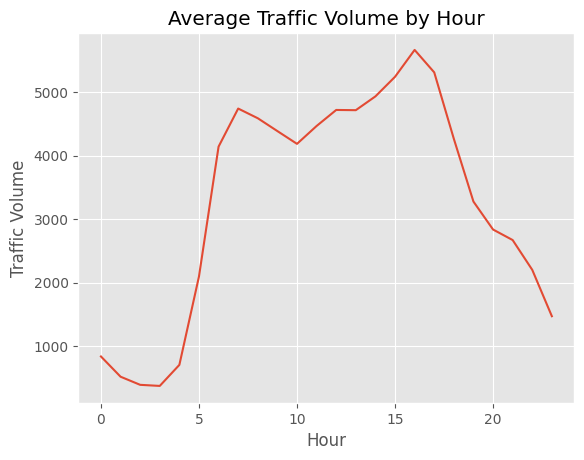

In [5]:
hourly = df.groupby('hour')['traffic_volume'].mean()

plt.figure()
hourly.plot()
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic Volume")
plt.show()

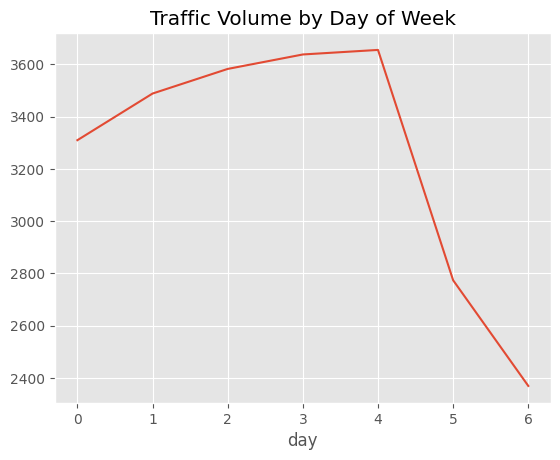

In [6]:
daily = df.groupby('day')['traffic_volume'].mean()

plt.figure()
daily.plot()
plt.title("Traffic Volume by Day of Week")
plt.show()

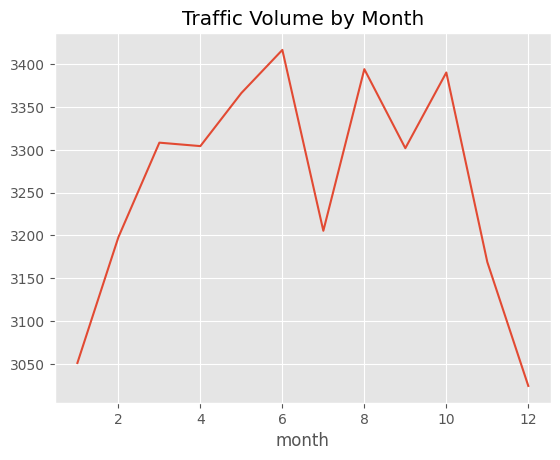

In [7]:
monthly = df.groupby('month')['traffic_volume'].mean()

plt.figure()
monthly.plot()
plt.title("Traffic Volume by Month")
plt.show()

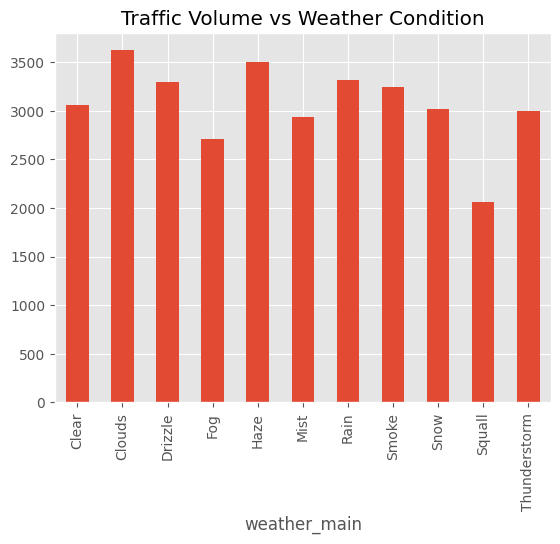

In [8]:
weather = df.groupby('weather_main')['traffic_volume'].mean()

plt.figure()
weather.plot(kind='bar')
plt.title("Traffic Volume vs Weather Condition")
plt.show()

In [9]:
# co-rel
df[['traffic_volume', 'temp', 'hour', 'day', 'month']].corr()

,traffic_volume,temp,hour,day,month
traffic_volume,1.000000,0.130161,0.352300,-0.149551,-0.002480
temp,0.130161,1.000000,0.112048,-0.007824,0.223943
hour,0.352300,0.112048,1.000000,-0.003808,0.001844
day,-0.149551,-0.007824,-0.003808,1.000000,0.010762
month,-0.002480,0.223943,0.001844,0.010762,1.000000


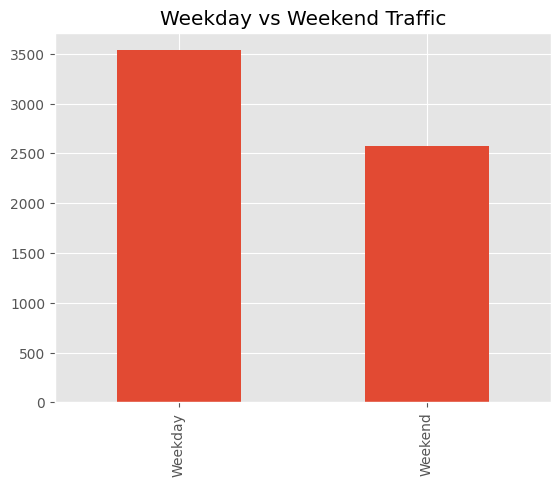

In [10]:
df['is_weekend'] = df['day'].apply(lambda x: 1 if x >= 5 else 0)

weekend = df.groupby('is_weekend')['traffic_volume'].mean()

weekend.index = ['Weekday', 'Weekend']

plt.figure()
weekend.plot(kind='bar')
plt.title("Weekday vs Weekend Traffic")
plt.show()

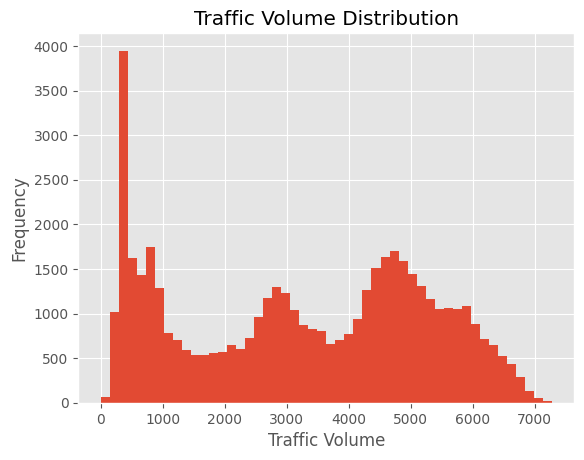

In [11]:
plt.figure()
df['traffic_volume'].hist(bins=50)
plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

In [12]:
hourly = df.groupby('hour')['traffic_volume'].mean()

peak_hour = hourly.idxmax()
print("Peak Traffic Hour:", peak_hour)

Peak Traffic Hour: 16
